In [1]:
# khai bao thu vien
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# duong dan den thu muc
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists():
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

DATA_DIR = ROOT_DIR / "dataset" / "foodDeli_processed"
WEIGHTS_DIR = ROOT_DIR / "results" / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_processed.csv"

print(ROOT_DIR)

c:\toanToiUu


In [3]:
# doc du lieu
train_df = pd.read_csv(TRAIN_PATH)
print(train_df.shape)
display(train_df.head())

(37554, 23)


,Delivery_person_Age,Delivery_person_Ratings,Distance_km,Preparation_Time,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Road_traffic_density_Jam,...,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Vehicle_condition_1,Vehicle_condition_2,Festival_Yes,City_Semi-Urban,City_Urban,Time_taken
0,1.283313,0.846622,-1.202059,1.228728,0,0,0,1,0,0,...,0,1,1,0,0,1,0,0,1,24
1,0.762428,-0.418372,2.263776,-1.218497,0,0,1,0,0,1,...,0,1,0,1,0,1,0,0,0,33
2,-1.147486,-0.734620,-1.118905,1.228728,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,26
3,1.456942,0.214125,-0.035496,0.005115,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,21
4,0.415171,-0.102123,-0.613995,1.228728,0,0,0,0,0,0,...,0,1,0,1,1,0,0,0,0,30


In [4]:
# chon cot muc tieu
TARGET_COL = "Time_taken"
print("Target:", TARGET_COL)

Target: Time_taken


In [5]:
# tach tap du lieu train_processed.csv 80/20
np.random.seed(42)

shuffled_indices = np.random.permutation(len(train_df))
split_idx = int(len(train_df) * 0.8)

train_indices = shuffled_indices[:split_idx]
test_indices = shuffled_indices[split_idx:]

data_train = train_df.iloc[train_indices].reset_index(drop=True)
data_test = train_df.iloc[test_indices].reset_index(drop=True)

print("Train split:", data_train.shape)
print("Test split :", data_test.shape)

Train split: (30043, 23)
Test split : (7511, 23)


In [6]:
# tach du lieu thanh X va y
X_train = data_train.drop(columns=[TARGET_COL]).to_numpy(dtype=float)
y_train = data_train[TARGET_COL].to_numpy(dtype=float)

X_test = data_test.drop(columns=[TARGET_COL]).to_numpy(dtype=float)
y_test = data_test[TARGET_COL].to_numpy(dtype=float)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (30043, 22)
y_train: (30043,)
X_test : (7511, 22)
y_test : (7511,)


In [7]:
# them bias vao X_train va X_test
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

print("X_train with bias:", X_train.shape)
print("X_test with bias :", X_test.shape)

X_train with bias: (30043, 23)
X_test with bias : (7511, 23)


In [8]:
# goi mo hinh va thuat toan toi uu
from src.optimizers.MomentumOptimizerHandMade import MomentumOptimizerHandMade
from src.models.quantile_regression import QuantileRegressionV1

In [9]:
# khoi tao momentum optimizer
optimizer = MomentumOptimizerHandMade(learning_rate=0.001,momentum=0.9)
print(optimizer)

MomentumOptimizerHandMade(learning_rate=0.001, momentum=0.9)


In [17]:
# huan luyen mo hinh voi momentum optimizer
model = QuantileRegressionV1(tau=0.9, optimizer=optimizer)
model.fit(X_train, y_train, epochs=500000, verbose=100)

Epoch 0/500000, Loss: 23.8476
Epoch 100/500000, Loss: 22.1289
Epoch 200/500000, Loss: 20.2404
Epoch 300/500000, Loss: 18.3518
Epoch 400/500000, Loss: 16.4637
Epoch 500/500000, Loss: 14.6158
Epoch 600/500000, Loss: 12.8747
Epoch 700/500000, Loss: 11.2684
Epoch 800/500000, Loss: 9.8559
Epoch 900/500000, Loss: 8.6495
Epoch 1000/500000, Loss: 7.6125
Epoch 1100/500000, Loss: 6.7147
Epoch 1200/500000, Loss: 5.9418
Epoch 1300/500000, Loss: 5.2821
Epoch 1400/500000, Loss: 4.7212
Epoch 1500/500000, Loss: 4.2511
Epoch 1600/500000, Loss: 3.8599
Epoch 1700/500000, Loss: 3.5353
Epoch 1800/500000, Loss: 3.2649
Epoch 1900/500000, Loss: 3.0413
Epoch 2000/500000, Loss: 2.8563
Epoch 2100/500000, Loss: 2.7021
Epoch 2200/500000, Loss: 2.5735
Epoch 2300/500000, Loss: 2.4644
Epoch 2400/500000, Loss: 2.3720
Epoch 2500/500000, Loss: 2.2928
Epoch 2600/500000, Loss: 2.2244
Epoch 2700/500000, Loss: 2.1650
Epoch 2800/500000, Loss: 2.1127
Epoch 2900/500000, Loss: 2.0670
Epoch 3000/500000, Loss: 2.0267
Epoch 3100/5

In [18]:
# in trong so sau khi huan luyen
print("Theta cuối cùng:")
print(model.theta)

Theta cuối cùng:
[ 4.08566937e+01  2.39397139e+00 -2.20472887e+00  1.57510484e+00
  7.38992189e-04  6.25126878e-01 -4.08483673e+00 -4.13253030e+00
 -4.31936891e+00 -4.01535233e+00  2.88892987e+00 -6.54027198e+00
 -8.86424125e-01  9.63819685e-02  2.96048285e-01  3.51379582e-01
  1.64205994e+00  1.25369748e+00 -5.46189524e+00 -5.14033782e+00
  7.96389741e+00  6.36019971e+00 -1.57898608e+00]


In [19]:
# du doan tren tap test
y_pred = model.predict(X_test)

In [20]:
# danh gia mo hinh
pinball_loss = model.pinball_loss(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print("Pinball Loss:", pinball_loss)
print("MAE         :", mae)
print("RMSE        :", rmse)

Pinball Loss: 1.0852187239338216
MAE         : 8.527422079708591
RMSE        : 10.115595505170056


In [21]:
print(type(model.loss))
print(len(model.loss))

<class 'list'>
500000


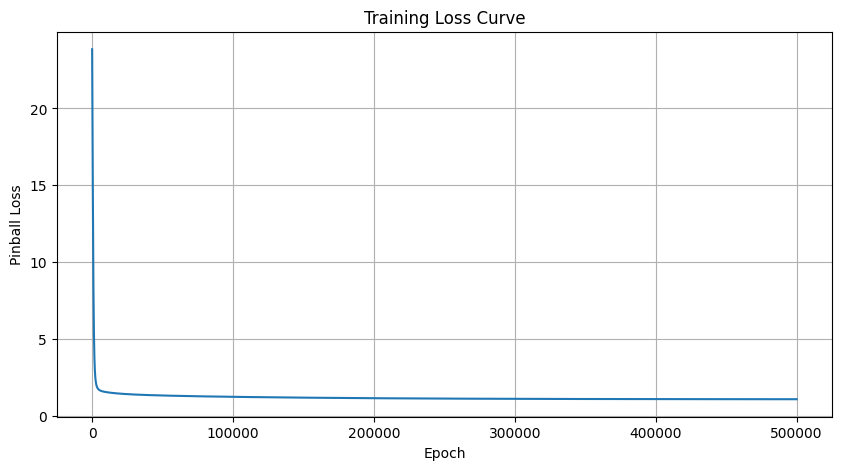

In [22]:
# ve bieu do loss
plt.figure(figsize=(10,5))
plt.plot(model.loss)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Pinball Loss")
plt.grid(True)
plt.show()

In [ ]:
# luu weights va loss history
np.save(WEIGHTS_DIR / "momentum_weights.npy", model.theta)
np.save( WEIGHTS_DIR / "momentum_loss_history.npy", np.array(model.loss) )
print("Đã lưu xong vào thư mục weights.")

Đã lưu xong vào thư mục weights.
